In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from brian2 import *
import functions as fc

In [3]:
simtime2 = 600*10**3 * ms
simtime3 = 300*10**3 * ms + 50*10**3 * ms

In [4]:
data_b = np.load('analysis_b.npz', allow_pickle=True)
data_c = np.load(f'analysis_c_new_2.npz', allow_pickle=True)

In [5]:
SpikeMon_t = data_b['SpikeMon_t'] 
SpikeMon_i = data_b['SpikeMon_i'] 
Current_t = data_b['Current_t'] 
Current_inh = data_b['Current_inh']
Current_exc = data_b['Current_exc']
SpikeTrains = data_b['SpikeTrainE'].item()
RateMonE_t = data_c['RateMonE_t'] 
RateMonE_rate = data_c['RateMonE_rate']

In [6]:
mask_1 = SpikeMon_t <= 0.2
mask_3 = SpikeMon_t >= (simtime2 / second) - 0.2

In [7]:
cv_dist_start = fc.get_isi_cv(N=800, spike_trains=SpikeTrains, t_min=0*ms, t_max=500*ms)
mean_cv_start = np.mean(cv_dist_start)
cv_dist_end = fc.get_isi_cv(N=800, spike_trains=SpikeTrains, t_min=simtime2 - 1000*ms, t_max=simtime2)
mean_cv_end = np.mean(cv_dist_end)

In [8]:
correlations_end = fc.get_spike_correlations(spike_times=SpikeTrains, t_min=(simtime2 - 1000*ms)/ms, t_max=simtime2/ms)
correlations_start = fc.get_spike_correlations(spike_times=SpikeTrains, t_min=0, t_max=500)
mean_corr_start = np.nanmean(correlations_start)
mean_corr_end = np.nanmean(correlations_end)

In [9]:
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import plot_config

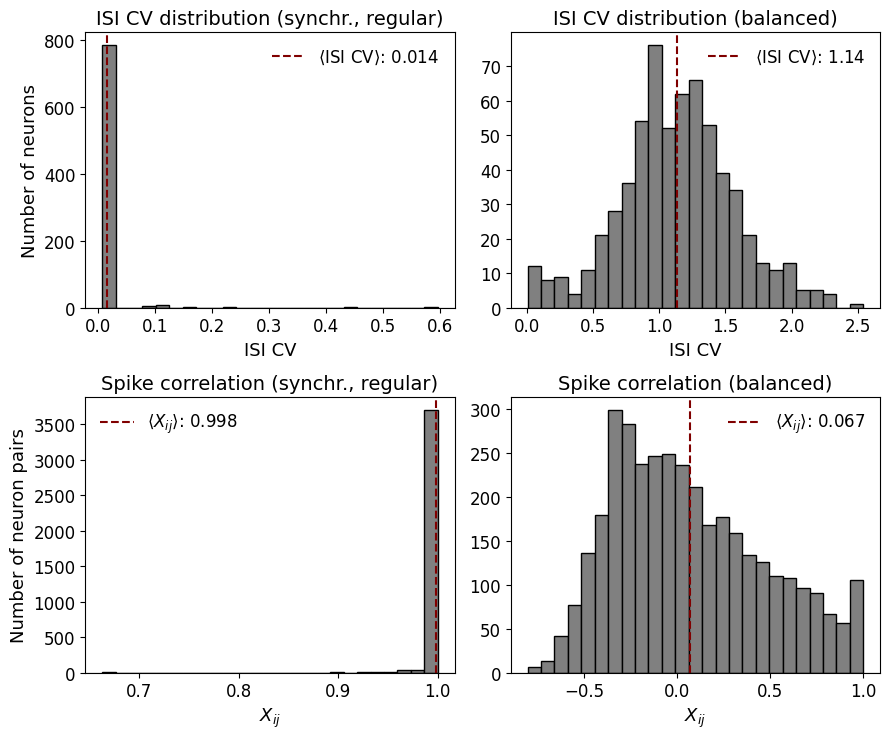

In [10]:
fig = plt.figure(figsize=(9, 7.5))
gs = GridSpec(2, 2, figure=fig)  

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(cv_dist_start, bins=25, color='grey', edgecolor='black', alpha=1)
ax1.axvline(mean_cv_start, color='maroon', ls='--', label=f'$\\langle \\text{{ISI CV}} \\rangle$: {np.round(mean_cv_start, 3)}')
ax1.axhline(0, color='k', lw=0.8)
ax1.set_xlabel('ISI CV')
ax1.set_ylabel('Number of neurons')
ax1.legend(frameon=False)
ax1.set_title('ISI CV distribution (synchr., regular)')

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(cv_dist_end, bins=25, color='grey', edgecolor='black', alpha=1)
ax2.axvline(mean_cv_end, color='maroon', ls='--', label=f'$\\langle \\text{{ISI CV}} \\rangle$: {np.round(mean_cv_end, 2)}')
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xlabel('ISI CV')
ax2.legend(frameon=False)
ax2.set_title('ISI CV distribution (balanced)')

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(correlations_start, bins=25, color='grey', edgecolor='black', alpha=1)
ax3.axvline(mean_corr_start, color='maroon', ls='--', label=f'$\\langle X_{{ij}} \\rangle$: {np.round(mean_corr_start, 3)}')
ax3.axhline(0, color='k', lw=0.8)
ax3.set_xlabel('$X_{ij}$')
ax3.set_ylabel('Number of neuron pairs')
ax3.legend(frameon=False)
ax3.set_title('Spike correlation (synchr., regular)')

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(correlations_end, bins=25, color='grey', edgecolor='black', alpha=1)
ax4.axvline(mean_corr_end, color='maroon', ls='--', label=f'$\\langle X_{{ij}} \\rangle$: {np.round(mean_corr_end, 3)}')
ax4.axhline(0, color='k', lw=0.8)
ax4.set_xlabel('$X_{ij}$')
ax4.legend(frameon=False)
ax4.set_title('Spike correlation (balanced)')

plt.tight_layout()
plt.savefig('./Plots/statistics.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/statistics.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()

WARNING    /tmp/ipykernel_11401/13256921.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 [py.warnings]


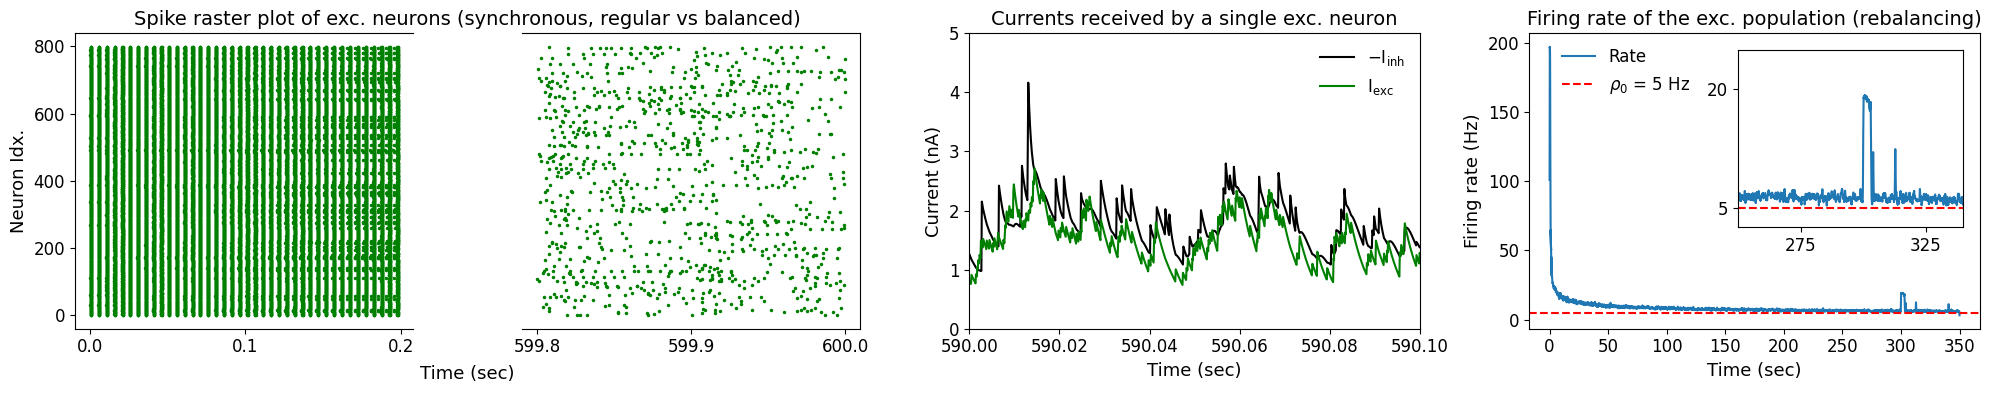

In [22]:
fig = plt.figure(figsize=(20, 4))
gs = GridSpec(1, 4, figure=fig, width_ratios=[0.75, 0.75, 1, 1])  

ax1 = fig.add_subplot(gs[0])
ax1.plot(SpikeMon_t[mask_1], SpikeMon_i[mask_1], '.g', ms=3)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('Neuron Idx.')
ax1.set_xticks([0, 0.1, 0.2])

ax2 = fig.add_subplot(gs[1])
ax2.plot(SpikeMon_t[mask_3], SpikeMon_i[mask_3], '.g', ms=3)
ax2.spines['left'].set_visible(False)
ax2.set_xticks([599.8, 599.9, 600])
ax2.set_yticks([])
ax2.ticklabel_format(style='plain', useOffset=False)

bbox1 = ax1.get_position()
bbox2 = ax2.get_position()

x_center = 0.5 * (bbox1.x0 + bbox2.x1)
y_bottom = min(bbox1.y0, bbox2.y0)
y_top = max(bbox1.y1, bbox2.y1)

fig.text(
    x_center - 0.05,
    y_bottom - 0.035,
    'Time (sec)',
    ha='center',
    va='top',
    fontsize=13
)
fig.text(
    x_center - 0.05,
    y_top + 0.035,
    'Spike raster plot of exc. neurons (synchronous, regular vs balanced)',
    ha='center',
    va='bottom',
    fontsize=14
)

ax3 = fig.add_subplot(gs[2])
ax3.plot(Current_t, -Current_inh[0], color='black', label="$-\\text{I}_{\\text{inh}}$")
ax3.plot(Current_t, Current_exc[0], color='green', label="$\\text{I}_{\\text{exc}}$")
ax3.set_ylim([0, 5])
ax3.set_xlim([590, 590.1])
ax3.legend(frameon=False, loc='upper right')
ax3.set_title('Currents received by a single exc. neuron')
ax3.set_ylabel('Current (nA)')
ax3.set_xlabel('Time (sec)')

ax4 = fig.add_subplot(gs[3])
ax4.plot(RateMonE_t, RateMonE_rate, label="Rate")
ax4.axhline(5, linestyle='--', color='red', label='$\\rho_{0}$ = 5 Hz')
ax4.set_ylabel('Firing rate (Hz)')
ax4.set_xlabel('Time (sec)')
axins = inset_axes(
    ax4,
    width="50%",    
    height="60%",
    loc="upper right",
    borderpad=1
)
ax4.legend(loc='upper left', bbox_to_anchor=(0.04, 1.0), frameon=False)
ax4.set_title('Firing rate of the exc. population (rebalancing)')
axins.plot(RateMonE_t, RateMonE_rate)
axins.axhline(5, linestyle='--', color='red')
axins.set_ylim(2.5, 25)
axins.set_xticks([275, 325])
axins.set_xlim([simtime3/second - 100, simtime3/second - 10])
axins.ticklabel_format(style='plain', useOffset=False)
axins.set_yticks([5, 20])

plt.tight_layout()
plt.savefig('./Plots/supplementary.png', format='png', dpi=300, bbox_inches="tight")
plt.savefig('./Plots/supplementary.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()